In [1]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from segment_anything import sam_model_registry, SamPredictor
from segment_anything import SamAutomaticMaskGenerator

In [2]:
sam_checkpoint = "sam_vit_b.pth"
model_type = "vit_b"
device = "cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device)

Sam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): Linear(in_features=3072, out_features=768, bias=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(768, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): LayerNorm2d()
    )


In [3]:
image = cv2.imread("stick.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

# anything brighter than 10 becomes white
_, mask = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)

mask = mask.astype(bool)


In [ ]:
# mask_generator = SamAutomaticMaskGenerator(
#     sam,
#     points_per_side=32,          # improves detection for drawings
#     pred_iou_thresh=0.86,
#     stability_score_thresh=0.90,
#     min_mask_region_area=10,     # removes tiny fragments
#     crop_n_layers=1
# )

mask_generator = SamAutomaticMaskGenerator(
    sam,
    points_per_side=64,          # improves detection for drawings
    pred_iou_thresh=0.86,
    stability_score_thresh=0.92,
    min_mask_region_area=10,     # removes tiny fragments
)

masks = mask_generator.generate(image)

print(f"Found {len(masks)} masks")


Found 8 masks


Mask 0: area ratio = 0.0025
Mask 1: area ratio = 0.0053
Mask 2: area ratio = 0.0091
Mask 3: area ratio = 0.0006
Mask 4: area ratio = 0.0010
Mask 5: area ratio = 0.0009
Mask 6: area ratio = 0.0005
Mask 7: area ratio = 0.8802


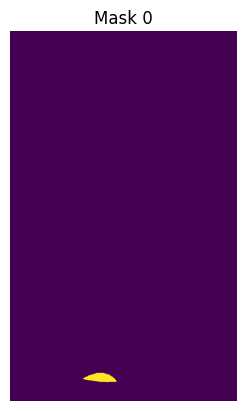

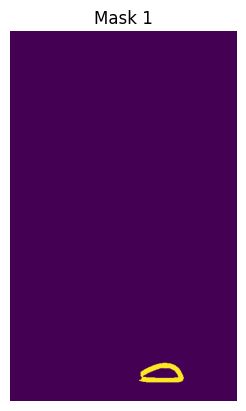

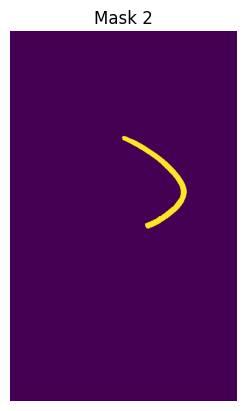

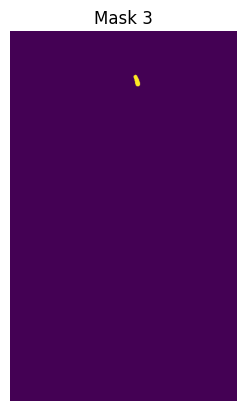

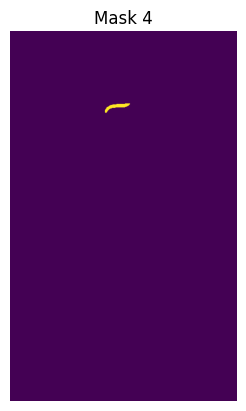

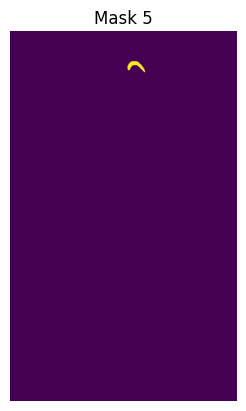

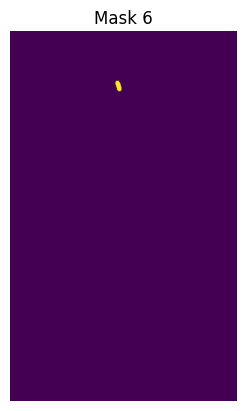

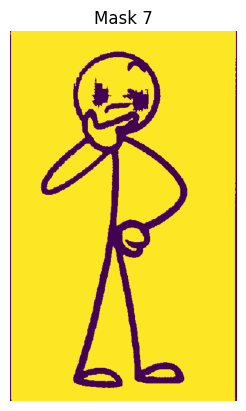

In [10]:
image_area = image.shape[0] * image.shape[1]

# valid_masks = []

# for i, m in enumerate(masks):

#     area_ratio = m["area"] / image_area
#     print(f"Mask {i}: area ratio = {area_ratio:.3f}")

#     # Ignore background (too large)
#     if area_ratio > 0.8:
#         continue

#     # Ignore tiny noise
#     if area_ratio < 0.001:
#         continue

#     valid_masks.append(m["segmentation"])

# if len(valid_masks) == 0:
#     raise ValueError("No valid masks found.")

center_y = image.shape[0] // 2
center_x = image.shape[1] // 2

valid_masks = []

for i, m in enumerate(masks):

    area_ratio = m["area"] / image_area
    seg = m["segmentation"]

    print(f"Mask {i}: area ratio = {area_ratio:.4f}")

    # visualize every mask
    plt.figure()
    plt.imshow(seg)
    plt.title(f"Mask {i}")
    plt.axis("off")

    # ignore background
    if area_ratio > 0.8:
        continue

    valid_masks.append(seg)

In [6]:
combined_mask = np.zeros_like(valid_masks[0], dtype=bool)

for m in valid_masks:
    combined_mask = combined_mask | m

(np.float64(-0.5), np.float64(451.5), np.float64(735.5), np.float64(-0.5))

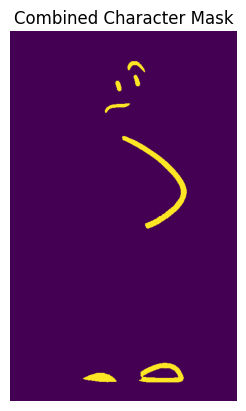

In [7]:
plt.figure()
plt.imshow(combined_mask)
plt.title("Combined Character Mask")
plt.axis("off")

(np.float64(-0.5), np.float64(451.5), np.float64(735.5), np.float64(-0.5))

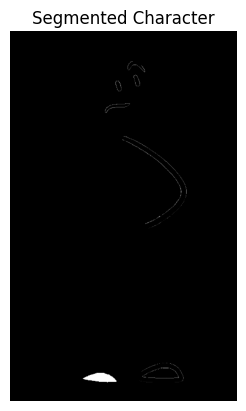

In [8]:
masked = image.copy()
masked[~combined_mask] = 0

plt.figure()
plt.imshow(masked)
plt.title("Segmented Character")
plt.axis("off")

In [9]:
rgba = np.dstack((masked, combined_mask * 255))
Image.fromarray(rgba.astype(np.uint8)).save("character.png")

print("Saved segmented character as character.png")

plt.show()

Saved segmented character as character.png
